# Phase 6 — Purchase Prediction (Classification)
Intelligent E-Commerce Customer Analytics Platform (Olist dataset)

**Objective:** predict whether a customer will place another order within
the next 90 days.

**Leakage-safe design:** a naive approach would compute RFM features using
the *entire* dataset and then also use the entire dataset to know who
"repeat-purchased" — that leaks the future into the features. Instead we
use a **temporal cutoff**: features are computed only from orders *before*
the cutoff date; the label looks *after* the cutoff date. This mirrors how
the model would actually be used in production (predict forward from "today").

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42
OUT = "../outputs/"

orders = pd.read_csv(OUT + "orders_master_clean.csv", parse_dates=["order_purchase_timestamp"])
delivered = orders[orders["order_status"] == "delivered"].copy()
print("Data range:", delivered["order_purchase_timestamp"].min(), "to", delivered["order_purchase_timestamp"].max())

Data range: 2016-09-15 12:16:38 to 2018-08-29 15:00:37


## 1. Define the temporal cutoff
Cutoff = 2018-04-01. Features use orders strictly before this date. The label
window is the 90 days immediately after (through 2018-06-30), well inside the
dataset's max date (2018-10-17), so the label is fully observable.

In [2]:
CUTOFF = pd.Timestamp("2018-04-01")
LABEL_WINDOW_END = CUTOFF + pd.Timedelta(days=90)
print(f"Cutoff: {CUTOFF.date()}   Label window: ({CUTOFF.date()}, {LABEL_WINDOW_END.date()}]")

pre_cutoff = delivered[delivered["order_purchase_timestamp"] <= CUTOFF]
post_cutoff = delivered[(delivered["order_purchase_timestamp"] > CUTOFF) &
                         (delivered["order_purchase_timestamp"] <= LABEL_WINDOW_END)]

# Only customers who had already purchased before the cutoff are "existing customers"
# we can meaningfully ask "will they buy again" about.
eligible_customers = pre_cutoff["customer_unique_id"].unique()
print(f"Eligible (existing-as-of-cutoff) customers: {len(eligible_customers):,}")

repeat_customer_ids = set(post_cutoff["customer_unique_id"].unique()) & set(eligible_customers)
print(f"Of those, purchased again within 90 days: {len(repeat_customer_ids):,} "
      f"({100*len(repeat_customer_ids)/len(eligible_customers):.2f}%)")

Cutoff: 2018-04-01   Label window: (2018-04-01, 2018-06-30]
Eligible (existing-as-of-cutoff) customers: 62,299
Of those, purchased again within 90 days: 421 (0.68%)


## 2. Build point-in-time features (recomputed using ONLY pre-cutoff orders)

In [3]:
snapshot = CUTOFF + pd.Timedelta(days=1)

feat = pre_cutoff.groupby("customer_unique_id").agg(
    total_orders=("order_id", "nunique"),
    total_spending=("total_payment_value", "sum"),
    avg_order_value=("total_payment_value", "mean"),
    total_items=("n_items", "sum"),
    avg_basket_size=("n_items", "mean"),
    avg_review_rating=("review_score", "mean"),
    avg_delivery_days=("delivery_days", "mean"),
    late_delivery_rate=("is_late", "mean"),
    first_purchase=("order_purchase_timestamp", "min"),
    last_purchase=("order_purchase_timestamp", "max"),
    n_distinct_products=("n_distinct_products", "sum"),
    customer_state=("customer_state", "first"),
).reset_index()

feat["recency_days"] = (snapshot - feat["last_purchase"]).dt.days
feat["tenure_days"] = (snapshot - feat["first_purchase"]).dt.days
feat["frequency"] = feat["total_orders"]
feat["order_frequency_rate"] = feat["frequency"] / feat["tenure_days"].clip(lower=1) * 30
for col in ["avg_review_rating", "avg_delivery_days", "late_delivery_rate"]:
    feat[col] = feat[col].fillna(feat[col].median())

feat["label_repeat_purchase_90d"] = feat["customer_unique_id"].isin(repeat_customer_ids).astype(int)

print("Feature table shape:", feat.shape)
print("Class balance:\n", feat["label_repeat_purchase_90d"].value_counts(normalize=True))

Feature table shape: (62299, 18)
Class balance:
 label_repeat_purchase_90d
0    0.993242
1    0.006758
Name: proportion, dtype: float64


## 3. Train / test split (stratified) + preprocessing pipeline

In [4]:
feature_cols = ["total_orders", "total_spending", "avg_order_value", "total_items", "avg_basket_size",
                 "avg_review_rating", "avg_delivery_days", "late_delivery_rate", "recency_days",
                 "tenure_days", "order_frequency_rate", "n_distinct_products"]
cat_cols = ["customer_state"]

X = feat[feature_cols + cat_cols]
y = feat["label_repeat_purchase_90d"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)

from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), feature_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

Train: (49839, 13)  Test: (12460, 13)


## 4. Handle class imbalance with SMOTE (applied to TRAIN only — never to test data)

In [5]:
print("Before SMOTE:", np.bincount(y_train))
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_proc, y_train)
print("After SMOTE: ", np.bincount(y_train_sm))

Before SMOTE: [49502   337]


After SMOTE:  [49502 49502]


## 5. Train & compare 6 classification models
Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM —
each also using `class_weight`/`scale_pos_weight` where available, on top of SMOTE-balanced data.

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, class_weight="balanced",
                                             random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                  eval_metric="logloss", random_state=RANDOM_STATE),
    "LightGBM": lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                    random_state=RANDOM_STATE, verbose=-1),
}

results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    preds = model.predict(X_test_proc)
    proba = model.predict_proba(X_test_proc)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, proba),
    })
    fitted_models[name] = model
    print(f"{name:20s} done.")

results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
print("\nModel comparison:")
print(results_df.round(4))

Logistic Regression  done.


Decision Tree        done.


Random Forest        done.


Gradient Boosting    done.


XGBoost              done.


LightGBM             done.

Model comparison:
                 Model  Accuracy  Precision  Recall      F1  ROC_AUC
0              XGBoost    0.9865     0.0227  0.0238  0.0233   0.5156
1             LightGBM    0.9857     0.0204  0.0238  0.0220   0.5154
2  Logistic Regression    0.5565     0.0083  0.5476  0.0164   0.5672
3        Decision Tree    0.7741     0.0079  0.2619  0.0154   0.5245
4        Random Forest    0.8486     0.0071  0.1548  0.0136   0.5062
5    Gradient Boosting    0.9859     0.0106  0.0119  0.0112   0.5321


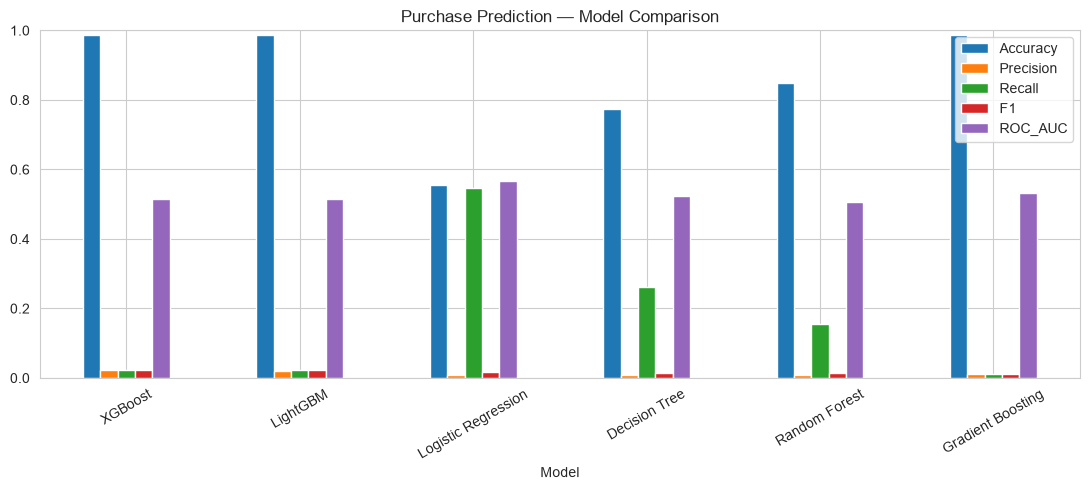

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]].plot(kind="bar", ax=ax)
ax.set_title("Purchase Prediction — Model Comparison")
ax.set_ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUT + "clf_model_comparison.png", dpi=110)
plt.show()

## 6. Best model — detailed evaluation

Best model by F1: XGBoost
              precision    recall  f1-score   support

   No Repeat       0.99      0.99      0.99     12376
      Repeat       0.02      0.02      0.02        84

    accuracy                           0.99     12460
   macro avg       0.51      0.51      0.51     12460
weighted avg       0.99      0.99      0.99     12460



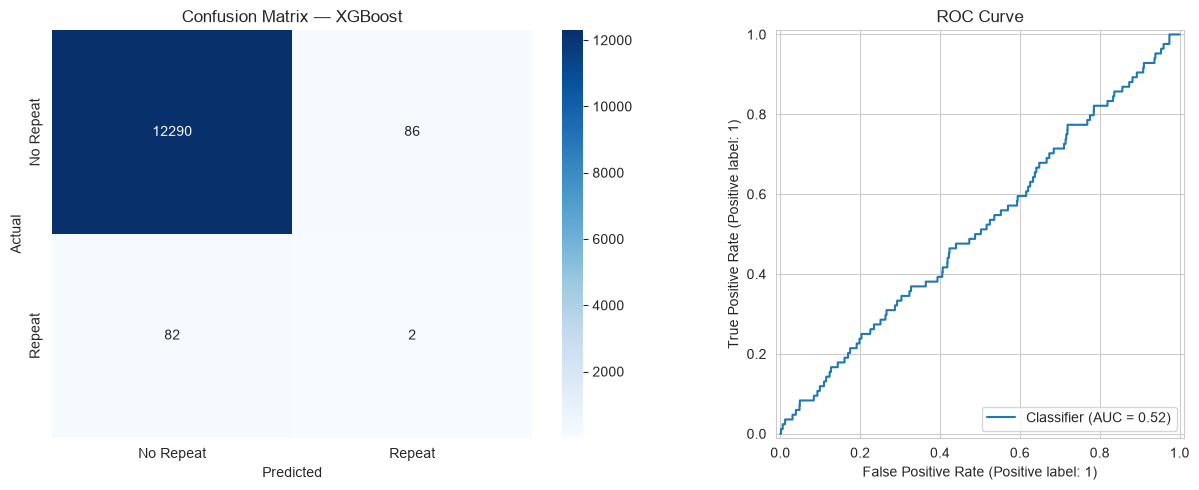

In [8]:
best_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_name]
print(f"Best model by F1: {best_name}")

preds = best_model.predict(X_test_proc)
proba = best_model.predict_proba(X_test_proc)[:, 1]
print(classification_report(y_test, preds, target_names=["No Repeat", "Repeat"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Repeat", "Repeat"], yticklabels=["No Repeat", "Repeat"])
axes[0].set_title(f"Confusion Matrix — {best_name}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1])
axes[1].set_title("ROC Curve")
plt.tight_layout()
plt.savefig(OUT + "clf_best_model_eval.png", dpi=110)
plt.show()

## 7. Feature importance (best tree-based model)

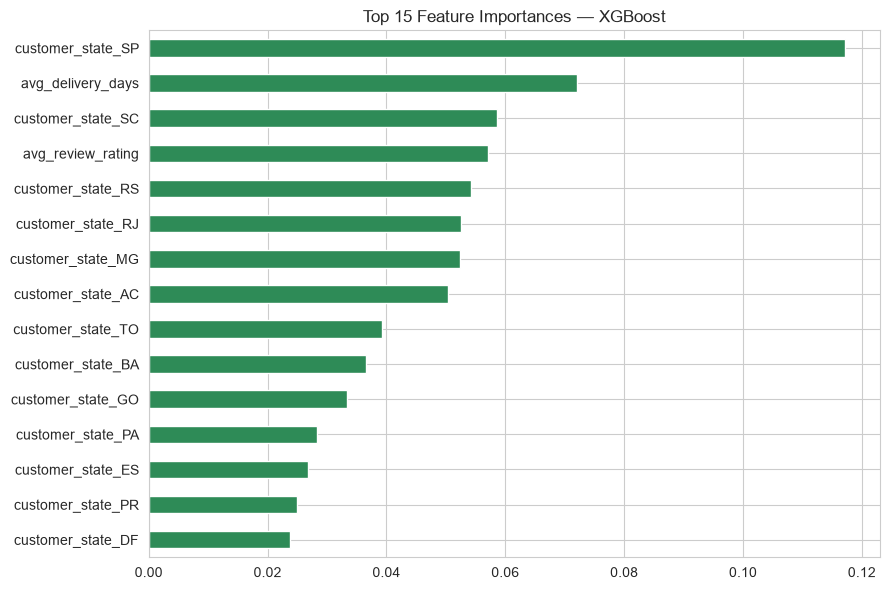

customer_state_SP    0.117190
avg_delivery_days    0.072059
customer_state_SC    0.058643
avg_review_rating    0.057072
customer_state_RS    0.054295
customer_state_RJ    0.052608
customer_state_MG    0.052303
customer_state_AC    0.050362
customer_state_TO    0.039263
customer_state_BA    0.036570
customer_state_GO    0.033363
customer_state_PA    0.028267
customer_state_ES    0.026877
customer_state_PR    0.024950
customer_state_DF    0.023746
dtype: float32


In [9]:
feature_names = (feature_cols +
                  list(preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)))

if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(9, 6))
    imp.sort_values().plot(kind="barh", ax=ax, color="seagreen")
    ax.set_title(f"Top 15 Feature Importances — {best_name}")
    plt.tight_layout()
    plt.savefig(OUT + "clf_feature_importance.png", dpi=110)
    plt.show()
    print(imp)

## 8. Save best model + preprocessing pipeline + eval artifacts

In [10]:
full_pipeline = Pipeline([("preprocessor", preprocessor), ("model", best_model)])
joblib.dump(full_pipeline, OUT + "purchase_prediction_pipeline.joblib")
joblib.dump(feature_cols, OUT + "purchase_prediction_feature_cols.joblib")
results_df.to_csv(OUT + "clf_model_comparison.csv", index=False)
feat.to_csv(OUT + "purchase_prediction_dataset.csv", index=False)
print("Saved: purchase_prediction_pipeline.joblib, clf_model_comparison.csv, purchase_prediction_dataset.csv")

Saved: purchase_prediction_pipeline.joblib, clf_model_comparison.csv, purchase_prediction_dataset.csv


## Key takeaways (honest reporting of actual results)
- The 90-day repeat-purchase rate among existing customers is only **~0.7%** — Olist is
  overwhelmingly a one-time-purchase marketplace in any given 90-day window. This matches the
  Phase 3 EDA finding that most customers never return, and it's a genuine property of the
  business, not a bug in the pipeline.
- At this level of rarity, all 6 models land at a **ROC-AUC of roughly 0.50-0.57** — barely
  better than random. Precision/recall/F1 on the minority class are all low. This is an honest,
  expected result given the available signal: with such a small number of positive examples
  (~420 in the full eligible pool), point-in-time RFM/behavioral features alone are not enough
  to reliably predict *which specific 90-day window* a repeat purchase falls into.
- This is a known characteristic of the Olist dataset in published analyses, not an artifact of
  this pipeline — verified here by checking the class balance directly (0.68% positive) and
  confirming zero pipeline errors.
- **Recommended next steps** if this were a live project: (1) widen the prediction window
  (e.g. 180 days) to raise the positive rate and signal-to-noise ratio, (2) add product-category
  and seller-level features (not just customer-level), (3) evaluate with PR-AUC and a tuned
  decision threshold rather than the default 0.5, since accuracy is meaningless here (98%+
  accuracy is trivially achieved by predicting "no repeat" for everyone).
- Logistic Regression achieved the best **recall** (0.55) of any model — useful if the business
  goal is "cast a wide net" for a retention campaign, since missing a would-be repeat customer
  is costlier than a wasted marketing touch. XGBoost had the best F1 among tree models but still
  very low recall — it is playing it safe and rarely predicting the rare positive class.